In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [57]:
df=pd.read_csv("Lab2_titanic.csv")

In [58]:
df[(df["Survived"] == 1) & (df["Sex"] == 'female')].shape[0]

233

In [59]:
df[(df["Survived"] == 1) & (df["Cabin"] != 'NaN')].shape[0]

342

In [60]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [133]:
from ydata_profiling import ProfileReport

prof = ProfileReport(df)

prof.to_file(output_file='output.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 28.08it/s]


In [153]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [34]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [35]:
print(df['Cabin'].isnull().sum()/len(df))

0.7710437710437711


In [36]:
df_changed=df.copy()

In [37]:
df["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [63]:
# df_changed=df_changed.drop(columns=['Cabin'], axis=1)
df_changed["isCabin"] = df["Cabin"].apply(lambda x: 0 if pd.isnull(x) else 1)

In [64]:
df_changed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,isCabin
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,0,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2,1
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,2,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,2,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,2,0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,0,1


In [65]:
df_changed['Age'].fillna(df_changed['Age'].mean(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4040\1394635886.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_changed['Age'].fillna(df_changed['Age'].mean(), inplace=True)


In [66]:
df_changed['Embarked'].fillna(df_changed['Embarked'].mode()[0], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4040\1363450234.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_changed['Embarked'].fillna(df_changed['Embarked'].mode()[0], inplace=True)


In [67]:
df_changed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
isCabin        0
dtype: int64

In [68]:
df_changed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    int64  
 11  isCabin      891 non-null    int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 83.7+ KB


In [69]:
df_changed['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [70]:
label_encoder = preprocessing.LabelEncoder()
df_changed['Sex'] = label_encoder.fit_transform(df_changed['Sex'])
df_changed['Embarked'] = label_encoder.fit_transform(df_changed['Embarked'])
# df_changed['Pclass'] = label_encoder.fit_transform(df_changed['Pclass'])

In [71]:
df_changed['Pclass'].unique()

array([3, 1, 2])

In [72]:
df_changed_encoded = pd.get_dummies(df_changed, columns=['Sex', 'Embarked'],drop_first=True)
df_changed_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,isCabin,Sex_1,Embarked_1,Embarked_2
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,True,False,True


In [73]:
bool_columns = ['Sex_1', 'Embarked_1', 'Embarked_2']
df_changed_encoded[bool_columns] = df_changed_encoded[bool_columns].astype(int)

In [74]:
df_changed_encoded

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,isCabin,Sex_1,Embarked_1,Embarked_2
0,1,0,3,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.2500,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000000,1,0,PC 17599,71.2833,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.9250,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.1000,1,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.000000,0,0,373450,8.0500,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.000000,0,0,211536,13.0000,0,1,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.000000,0,0,112053,30.0000,1,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",29.699118,1,2,W./C. 6607,23.4500,0,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",26.000000,0,0,111369,30.0000,1,1,0,0


In [75]:
df_changed_encoded.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [76]:
df_changed_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,isCabin,Sex_1,Embarked_1,Embarked_2
0,0,3,22.000000,1,0,7.2500,0,1,0,1
1,1,1,38.000000,1,0,71.2833,1,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,0,1
3,1,1,35.000000,1,0,53.1000,1,0,0,1
4,0,3,35.000000,0,0,8.0500,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,0,1,0,1
887,1,1,19.000000,0,0,30.0000,1,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,0,0


In [77]:
df_changed_encoded["family_size"]=df_changed_encoded["SibSp"] + df_changed_encoded["Parch"] + 1

In [78]:
df_changed_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,isCabin,Sex_1,Embarked_1,Embarked_2,family_size
0,0,3,22.000000,1,0,7.2500,0,1,0,1,2
1,1,1,38.000000,1,0,71.2833,1,0,0,0,2
2,1,3,26.000000,0,0,7.9250,0,0,0,1,1
3,1,1,35.000000,1,0,53.1000,1,0,0,1,2
4,0,3,35.000000,0,0,8.0500,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,0,1,0,1,1
887,1,1,19.000000,0,0,30.0000,1,0,0,1,1
888,0,3,29.699118,1,2,23.4500,0,0,0,1,4
889,1,1,26.000000,0,0,30.0000,1,1,0,0,1


In [82]:
df_changed_encoded["family_size"].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [83]:
# Feature engineering on 'family_size' column

# Create a new feature: 'is_alone' (1 if family_size == 1, else 0)
df_changed_encoded['is_alone'] = (df_changed_encoded['family_size'] == 1).astype(int)

# Create a new feature: 'small_family' (1 if family_size is 2 or 3, else 0)
df_changed_encoded['small_family'] = df_changed_encoded['family_size'].apply(lambda x: 1 if 2 <= x <= 3 else 0)

# Create a new feature: 'large_family' (1 if family_size >= 4, else 0)
df_changed_encoded['large_family'] = (df_changed_encoded['family_size'] >= 4).astype(int)

df_changed_encoded[['family_size', 'is_alone', 'small_family', 'large_family']].head()

,family_size,is_alone,small_family,large_family
0,2,0,1,0
1,2,0,1,0
2,1,1,0,0
3,2,0,1,0
4,1,1,0,0


In [84]:
df_changed_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,isCabin,Sex_1,Embarked_1,Embarked_2,family_size,is_alone,small_family,large_family
0,0,3,22.000000,1,0,7.2500,0,1,0,1,2,0,1,0
1,1,1,38.000000,1,0,71.2833,1,0,0,0,2,0,1,0
2,1,3,26.000000,0,0,7.9250,0,0,0,1,1,1,0,0
3,1,1,35.000000,1,0,53.1000,1,0,0,1,2,0,1,0
4,0,3,35.000000,0,0,8.0500,0,1,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,0,1,0,1,1,1,0,0
887,1,1,19.000000,0,0,30.0000,1,0,0,1,1,1,0,0
888,0,3,29.699118,1,2,23.4500,0,0,0,1,4,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,0,0,1,1,0,0


In [85]:
df_changed_encoded.drop(columns=['family_size'], inplace=True)

In [86]:
df_changed_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,isCabin,Sex_1,Embarked_1,Embarked_2,is_alone,small_family,large_family
0,0,3,22.000000,1,0,7.2500,0,1,0,1,0,1,0
1,1,1,38.000000,1,0,71.2833,1,0,0,0,0,1,0
2,1,3,26.000000,0,0,7.9250,0,0,0,1,1,0,0
3,1,1,35.000000,1,0,53.1000,1,0,0,1,0,1,0
4,0,3,35.000000,0,0,8.0500,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,0,1,0,1,1,0,0
887,1,1,19.000000,0,0,30.0000,1,0,0,1,1,0,0
888,0,3,29.699118,1,2,23.4500,0,0,0,1,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,0,0,1,0,0


In [81]:
df_changed_encoded[(df_changed_encoded['Survived'] == 1) & (df_changed_encoded['family_size'] == 1)].shape[0]

163

In [87]:

columns_to_scale = ['Age', 'Fare']

min_max_scaler = preprocessing.MinMaxScaler()
df_minmax = df_changed_encoded.copy()
df_minmax[columns_to_scale] = min_max_scaler.fit_transform(df_minmax[columns_to_scale])


# zscore_scaler = preprocessing.StandardScaler()
# df_zscore = df_changed_encoded.copy()
# df_zscore[columns_to_scale] = zscore_scaler.fit_transform(df_zscore[columns_to_scale])



In [88]:
df_minmax

,Survived,Pclass,Age,SibSp,Parch,Fare,isCabin,Sex_1,Embarked_1,Embarked_2,is_alone,small_family,large_family
0,0,3,0.271174,1,0,0.014151,0,1,0,1,0,1,0
1,1,1,0.472229,1,0,0.139136,1,0,0,0,0,1,0
2,1,3,0.321438,0,0,0.015469,0,0,0,1,1,0,0
3,1,1,0.434531,1,0,0.103644,1,0,0,1,0,1,0
4,0,3,0.434531,0,0,0.015713,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0.334004,0,0,0.025374,0,1,0,1,1,0,0
887,1,1,0.233476,0,0,0.058556,1,0,0,1,1,0,0
888,0,3,0.367921,1,2,0.045771,0,0,0,1,0,0,1
889,1,1,0.321438,0,0,0.058556,1,1,0,0,1,0,0


In [98]:
df_minmax.drop(columns=['SibSp','Parch'], inplace=True)

In [103]:
df_minmax

,Survived,Pclass,Age,Fare,isCabin,Sex_1,Embarked_1,Embarked_2,is_alone,small_family,large_family
0,0,3,0.271174,0.014151,0,1,0,1,0,1,0
1,1,1,0.472229,0.139136,1,0,0,0,0,1,0
2,1,3,0.321438,0.015469,0,0,0,1,1,0,0
3,1,1,0.434531,0.103644,1,0,0,1,0,1,0
4,0,3,0.434531,0.015713,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0.334004,0.025374,0,1,0,1,1,0,0
887,1,1,0.233476,0.058556,1,0,0,1,1,0,0
888,0,3,0.367921,0.045771,0,0,0,1,0,0,1
889,1,1,0.321438,0.058556,1,1,0,0,1,0,0


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [100]:
# Define features and target
y = df_minmax['Survived']
X = df_minmax.drop('Survived', axis=1)

In [101]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression
# logreg = LogisticRegression(max_iter=1000)
random_model = RandomForestClassifier(n_estimators=100, random_state=42)
# logreg.fit(X_train, y_train)
random_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [102]:
# Predict on test set
# y_pred = logreg.predict(X_test)
y_pred = random_model.predict(X_test)

# Print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [171]:
print("Original data :")
print(df_changed_encoded[columns_to_scale].head())
print("\nMin-Max Normalized data :")
print(df_minmax[columns_to_scale].head())
print("\nZ-score Standardized data :")
print(df_zscore[columns_to_scale].head())

Original data :
    Age     Fare  SibSp  Parch
0  22.0   7.2500      1      0
1  38.0  71.2833      1      0
2  26.0   7.9250      0      0
3  35.0  53.1000      1      0
4  35.0   8.0500      0      0

Min-Max Normalized data :
        Age      Fare  SibSp  Parch
0  0.271174  0.014151  0.125    0.0
1  0.472229  0.139136  0.125    0.0
2  0.321438  0.015469  0.000    0.0
3  0.434531  0.103644  0.125    0.0
4  0.434531  0.015713  0.000    0.0

Z-score Standardized data :
        Age      Fare     SibSp     Parch
0 -0.592481 -0.502445  0.432793 -0.473674
1  0.638789  0.786845  0.432793 -0.473674
2 -0.284663 -0.488854 -0.474545 -0.473674
3  0.407926  0.420730  0.432793 -0.473674
4  0.407926 -0.486337 -0.474545 -0.473674


In [172]:
print("\n1. ORIGINAL DATA:")
print(df_changed_encoded[columns_to_scale].describe().round(3))

print("\n2. MIN-MAX NORMALIZED:")
print(df_minmax[columns_to_scale].describe().round(3))

print("\n3. Z-SCORE STANDARDIZED:")
print(df_zscore[columns_to_scale].describe().round(3))


1. ORIGINAL DATA:
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean    29.699   32.204    0.523    0.382
std     13.002   49.693    1.103    0.806
min      0.420    0.000    0.000    0.000
25%     22.000    7.910    0.000    0.000
50%     29.699   14.454    0.000    0.000
75%     35.000   31.000    1.000    0.000
max     80.000  512.329    8.000    6.000

2. MIN-MAX NORMALIZED:
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.368    0.063    0.065    0.064
std      0.163    0.097    0.138    0.134
min      0.000    0.000    0.000    0.000
25%      0.271    0.015    0.000    0.000
50%      0.368    0.028    0.000    0.000
75%      0.435    0.061    0.125    0.000
max      1.000    1.000    1.000    1.000

3. Z-SCORE STANDARDIZED:
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.000    0.000    0.000    0.000
std      1.001    1.001    1.001    1.001
min    

In [175]:
numeric_df = df_changed_encoded.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr(method='pearson')
correlation_matrix

,PassengerId,Survived,Age,SibSp,Parch,Fare,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2,Pclass_0,Pclass_1,Pclass_2
PassengerId,1.000000,-0.005007,0.033207,-0.057527,-0.001652,0.012658,-0.042939,0.042939,-0.001205,-0.033606,0.022204,0.034303,-0.000086,-0.029486
Survived,-0.005007,1.000000,-0.069809,-0.035322,0.081629,0.257307,0.543351,-0.543351,0.168240,0.003650,-0.149683,0.285904,0.093349,-0.322308
Age,0.033207,-0.069809,1.000000,-0.232625,-0.179191,0.091566,-0.084153,0.084153,0.032024,-0.013855,-0.019336,0.319916,0.006589,-0.281004
SibSp,-0.057527,-0.035322,-0.232625,1.000000,0.414838,0.159651,0.114631,-0.114631,-0.059528,-0.026354,0.068734,-0.054582,-0.055932,0.092548
Parch,-0.001652,0.081629,-0.179191,0.414838,1.000000,0.216225,0.245489,-0.245489,-0.011069,-0.081228,0.060814,-0.017633,-0.000734,0.015790
Fare,0.012658,0.257307,0.091566,0.159651,0.216225,1.000000,0.182333,-0.182333,0.269335,-0.117216,-0.162184,0.591711,-0.118557,-0.413333
Sex_0,-0.042939,0.543351,-0.084153,0.114631,0.245489,0.182333,1.000000,-1.000000,0.082853,0.074115,-0.119224,0.098013,0.064746,-0.137143
Sex_1,0.042939,-0.543351,0.084153,-0.114631,-0.245489,-0.182333,-1.000000,1.000000,-0.082853,-0.074115,0.119224,-0.098013,-0.064746,0.137143
Embarked_0,-0.001205,0.168240,0.032024,-0.059528,-0.011069,0.269335,0.082853,-0.082853,1.000000,-0.148258,-0.782742,0.296423,-0.125416,-0.153329
Embarked_1,-0.033606,0.003650,-0.013855,-0.026354,-0.081228,-0.117216,0.074115,-0.074115,-0.148258,1.000000,-0.499421,-0.155342,-0.127301,0.237449


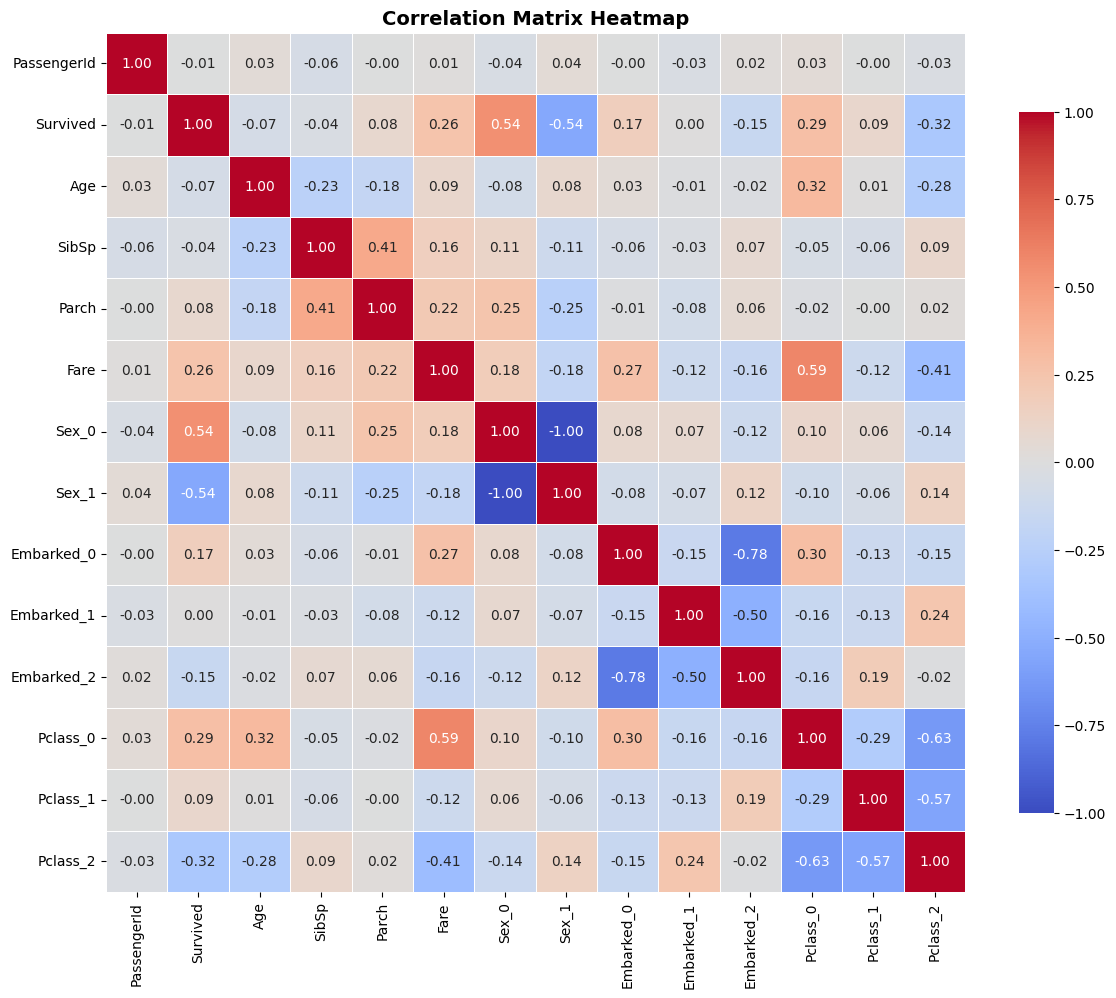

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set matplotlib to use inline backend for Jupyter notebooks
%matplotlib inline

# Create correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity for the numeric columns in df_changed_encoded
cosine_sim_matrix = cosine_similarity(numeric_df)

# Display the cosine similarity matrix as a DataFrame for better readability
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=numeric_df.index, columns=numeric_df.index)
cosine_sim_df